## Job Failure Prediction Baseline Models
### XGBoost, CatBoost, LightGBM

In [1]:
import polars as pl

# path = "/media/storage0/allison/BatchSystem-2024/0[1-2]/*.parquet"
# path = "/media/storage0/allison/BatchSystem-2024/01/*.parquet"
# job_data = pl.scan_parquet(path)

with open("../data/BatchSystemTrain.txt", "r") as f:
    columns = [line.strip().strip("'").strip('"') for line in f if line.strip()]

print(f"Loaded {len(columns)} columns from file.")

Loaded 30 columns from file.


In [2]:
%%time
path = "../data/processed_job_data_0[1-6].parquet"
job_data = pl.scan_parquet(path)

CPU times: user 288 μs, sys: 272 μs, total: 560 μs
Wall time: 456 μs


In [3]:
%%time
job_df = job_data.select(columns).collect()
print(job_df.shape) 

(41079913, 30)
CPU times: user 3.11 s, sys: 2.4 s, total: 5.5 s
Wall time: 552 ms


## Preprocessing

In [4]:
job_df.head()

Group,ClusterId,CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentStartExecutingDate_ms,JobCurrentWaitTime,JobPrio,JobUniverse,MATCH_EXP_JOB_GLIDEIN_Site,MemoryProvisioned,MinCores,MinHosts,Owner,POMS_LAUNCHER,POMS_TASK_ID,POMS4_CAMPAIGN_ID,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_ID,POMS4_CAMPAIGN_STAGE_NAME,ProcId,QDate_ms,RequestCpus,RequestDisk,Requestioslots,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB
str,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,i64,str,str,str,str,i64,i64,i64,i64,str,i64,i64,str,i64
"""group_uboone""",7126611,"""1""","""36607673""",15,86400,1704102734000,246,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",75269579,"""1""","""36604362""",15,43200,1704102014000,72,0,5,"""FermiGrid""","""3500""",null,1,"""uboonepro""","""mguzzo""",1688106,"""7879""","""prod_numi_wirecell_run4_fhc_mg…","""19253""","""ly_down""",0,1704101942000,1,31457280,null,3500,1,"""1""",0
"""group_uboone""",7126606,"""1""","""34787476""",15,86400,1704102740000,252,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",7126447,"""1""","""35124245""",15,86400,1704102630000,160,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102470000,1,31457280,null,2000,1,"""1""",0
"""group_icarus""",66506724,"""1""","""21209214""",75,43200,1704103406000,5833,0,5,"""FermiGrid""","""9990""",null,1,"""icaruspro""","""icaruspro""",1688063,"""7404""","""icarus_keepup_production_Offbe…","""18311""","""stage1_caf_larcv_auto""",0,1704097573000,1,20971520,null,2000,1,"""1""",0


In [5]:
%%time
STAGE_TYPES = ["generation", "reconstruction", "merging", "analysis"]

def stage_type_expr():
    lc_stage = pl.col("POMS4_CAMPAIGN_STAGE_NAME").str.to_lowercase()
    lc_camp = pl.col("POMS4_CAMPAIGN_NAME").str.to_lowercase()

    return (
        pl.when(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null() & pl.col("POMS4_CAMPAIGN_NAME").is_null())
        .then(pl.lit(None, dtype=pl.Utf8))

        # Generation & Simulation (Signal generation, physics models, variations)
        .when(
            lc_stage.str.contains("gen|g4|sim|dio|endpoint|leadinglog|corsika|resample|wire_mod|wiremod|ly_|lyattn|lydown|sce|theta|tpc|offset|mix|ensemble|rpc|spill|cv|run[0-9]+")
        )
        .then(pl.lit("generation"))

         # Reconstruction & Digitization (Raw processing / clusters / hits)
        .when(
            lc_stage.str.contains("reco|track|stage0|stage1|digi|decode|recluster|fullproduction|ndlar|compress|convert")
        )
        .then(pl.lit("reconstruction"))

        # Merging & Skimming (Reducing file counts/sizes)
        .when(
            lc_stage.str.contains("merge|skim|hadd|filter|scrub|watchdog|sleep|test|fclless")
        )
        .then(pl.lit("merging"))

        # High-Level Analysis (Ntuple and framework-specific file production)
        .when(
            lc_stage.str.contains("ana|caf|ntuple|larcv")
        )
        .then(pl.lit("analysis"))

        .otherwise(pl.lit("other_production"))
    )

stage_types = job_df.with_columns(stage_type_expr().alias("stage_type"))

CPU times: user 16.3 s, sys: 206 ms, total: 16.5 s
Wall time: 1.45 s


In [6]:
print("User jobs:", job_df.filter(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null()).shape[0], job_df.filter(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null()).shape[0] / job_df.shape[0] * 100, "%")
print("Production stage type counts (01-06/2024):")
prod_total = stage_types.filter(pl.col("stage_type").is_not_null()).shape[0]
summary_df = (
    stage_types.filter(pl.col("stage_type").is_not_null())
    .group_by("stage_type")
    .len()
    .with_columns(
        ((pl.col("len") / prod_total) * 100).alias("percentage")
    )
    .sort("len", descending=True)
)

print(summary_df)

User jobs: 27362188 66.60721993252517 %
Production stage type counts (01-06/2024):


shape: (5, 3)
┌──────────────────┬─────────┬────────────┐
│ stage_type       ┆ len     ┆ percentage │
│ ---              ┆ ---     ┆ ---        │
│ str              ┆ u32     ┆ f64        │
╞══════════════════╪═════════╪════════════╡
│ generation       ┆ 7126069 ┆ 51.947892  │
│ reconstruction   ┆ 4692912 ┆ 34.210571  │
│ merging          ┆ 1562088 ┆ 11.387369  │
│ other_production ┆ 211146  ┆ 1.53922    │
│ analysis         ┆ 125510  ┆ 0.914948   │
└──────────────────┴─────────┴────────────┘


### Attempt 1

In [7]:
other_campaigns_df = (
    stage_types.filter(pl.col("stage_type") == "other_production")
    .select(pl.col("POMS4_CAMPAIGN_STAGE_NAME"))
    .drop_nulls()
    .unique()
    .sort("POMS4_CAMPAIGN_STAGE_NAME")
)

other_campaigns_list = other_campaigns_df["POMS4_CAMPAIGN_STAGE_NAME"].to_list()

print(f"Found {len(other_campaigns_list)} unique campaign stage names categorized as 'other_production':\n")
for campaign in other_campaigns_list:
    print(f"- {campaign}")

Found 3 unique campaign stage names categorized as 'other_production':

- 2100
- 3200
- undefined


Columns that need to be converted to numeric:
- CpusProvisioned
- DiskProvisioned
- MemoryProvisioned
- TotalSubmitProcs


In [9]:
job_df.head()

Group,ClusterId,CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentStartExecutingDate_ms,JobCurrentWaitTime,JobPrio,JobUniverse,MATCH_EXP_JOB_GLIDEIN_Site,MemoryProvisioned,MinCores,MinHosts,Owner,POMS_LAUNCHER,POMS_TASK_ID,POMS4_CAMPAIGN_ID,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_ID,POMS4_CAMPAIGN_STAGE_NAME,ProcId,QDate_ms,RequestCpus,RequestDisk,Requestioslots,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB
str,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,i64,str,str,str,str,i64,i64,i64,i64,str,i64,i64,str,i64
"""group_uboone""",7126611,"""1""","""36607673""",15,86400,1704102734000,246,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",75269579,"""1""","""36604362""",15,43200,1704102014000,72,0,5,"""FermiGrid""","""3500""",null,1,"""uboonepro""","""mguzzo""",1688106,"""7879""","""prod_numi_wirecell_run4_fhc_mg…","""19253""","""ly_down""",0,1704101942000,1,31457280,null,3500,1,"""1""",0
"""group_uboone""",7126606,"""1""","""34787476""",15,86400,1704102740000,252,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",7126447,"""1""","""35124245""",15,86400,1704102630000,160,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102470000,1,31457280,null,2000,1,"""1""",0
"""group_icarus""",66506724,"""1""","""21209214""",75,43200,1704103406000,5833,0,5,"""FermiGrid""","""9990""",null,1,"""icaruspro""","""icaruspro""",1688063,"""7404""","""icarus_keepup_production_Offbe…","""18311""","""stage1_caf_larcv_auto""",0,1704097573000,1,20971520,null,2000,1,"""1""",0


In [10]:
job_data_clean = job_df.with_columns([
    pl.col("CpusProvisioned").cast(pl.Int32, strict=False),
    pl.col("DiskProvisioned").cast(pl.Int32, strict=False),
    pl.col("MemoryProvisioned").cast(pl.Int32, strict=False),
    pl.col("TotalSubmitProcs").cast(pl.Int32, strict=False),
    stage_type_expr().alias("stage_type")
])

cols_to_keep = [
    col_name for col_name in job_data_clean.columns
    if job_data_clean.select(pl.col(col_name).n_unique()).item() > 1
]
removed_cols = set(job_data_clean.columns) - set(cols_to_keep)
job_data_clean = job_data_clean.select(cols_to_keep)

print(f"Dropped {len(removed_cols)} columns with only one unique value:")
print(list(removed_cols))

job_data_clean.head()

Dropped 4 columns with only one unique value:
['MinHosts', 'MinCores', 'JobUniverse', 'Requestioslots']


Group,ClusterId,CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentStartExecutingDate_ms,JobCurrentWaitTime,JobPrio,MATCH_EXP_JOB_GLIDEIN_Site,MemoryProvisioned,Owner,POMS_LAUNCHER,POMS_TASK_ID,POMS4_CAMPAIGN_ID,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_ID,POMS4_CAMPAIGN_STAGE_NAME,ProcId,QDate_ms,RequestCpus,RequestDisk,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB,stage_type
str,i64,i32,i32,i64,i64,i64,i64,i64,str,i32,str,str,i64,str,str,str,str,i64,i64,i64,i64,i64,i64,i32,i64,str
"""group_uboone""",7126611,1,36607673,15,86400,1704102734000,246,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,2000,1,1,0,"""generation"""
"""group_uboone""",75269579,1,36604362,15,43200,1704102014000,72,0,"""FermiGrid""",3500,"""uboonepro""","""mguzzo""",1688106,"""7879""","""prod_numi_wirecell_run4_fhc_mg…","""19253""","""ly_down""",0,1704101942000,1,31457280,3500,1,1,0,"""generation"""
"""group_uboone""",7126606,1,34787476,15,86400,1704102740000,252,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,2000,1,1,0,"""generation"""
"""group_uboone""",7126447,1,35124245,15,86400,1704102630000,160,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102470000,1,31457280,2000,1,1,0,"""generation"""
"""group_icarus""",66506724,1,21209214,75,43200,1704103406000,5833,0,"""FermiGrid""",9990,"""icaruspro""","""icaruspro""",1688063,"""7404""","""icarus_keepup_production_Offbe…","""18311""","""stage1_caf_larcv_auto""",0,1704097573000,1,20971520,2000,1,1,0,"""generation"""


In [11]:
with open("../data/BatchSystemOutcomes.txt", "r") as f:
    outcome_cols = [line.strip().strip("'").strip('"') for line in f if line.strip()]

print(f"Loaded {len(outcome_cols)} columns from file.")

outcome_df = job_data.select(outcome_cols).collect()
print(outcome_df.shape) 

Loaded 8 columns from file.


(41079913, 8)


In [183]:
failures = outcome_df.filter((pl.col("ExitCode") != 0) | (pl.col("ExitSignal").is_not_null()) | (pl.col("JobStatus") == 3))
print("Total failures:", failures.shape[0])

Total failures: 7676794


In [13]:
import polars as pl
import numpy as np

full_job_df = pl.concat([job_data_clean, outcome_df], how="horizontal")

# Label cascade implementing README.md "Job Failure Definition" / "Label Construction".
# Rules apply top-down, first match wins.

# ExitCode tables (README: Non-null Exit Codes, null Exit Signal)
EXIT_CODE_USER = [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 22, 23, 28, 31, 32, 33,
                  65, 67, 68, 69, 71, 88, 90, 91, 124, 137]
EXIT_CODE_APP = [8, 15, 16, 17, 18, 19, 20, 21, 24, 25, 26, 27, 29, 30, 66, 70]
# ExitSignal table: crash signals + SIGKILL (OOM/eviction) + SIGXCPU -> Application;
# SIGTERM (draining / time limit / maintenance) and unlisted signals (122, 94, ...) -> System
SIGNAL_APP = [4, 6, 7, 8, 9, 11, 24]

rr = pl.col("RemoveReason").fill_null("")

outcome_expr = (
    # A. SUCCESS: exit code 0, no signal, and not removed from the queue
    pl.when((pl.col("ExitCode") == 0) & pl.col("ExitSignal").is_null() &
            (pl.col("JobStatus") != 3))
    .then(pl.lit("Success"))

    # B. EXIT SIGNALS (take precedence when both a code and a signal are present)
    .when(pl.col("ExitSignal").is_in(SIGNAL_APP)).then(pl.lit("Failure_Application"))
    .when(pl.col("ExitSignal").is_not_null()).then(pl.lit("Failure_System"))

    # C. EXIT CODES per the art/README table; unlisted non-zero codes (127, 255, ...) -> Application
    .when(pl.col("ExitCode").is_in(EXIT_CODE_USER)).then(pl.lit("Failure_User"))
    .when(pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0))
    .then(pl.lit("Failure_Application"))

    # D. REMOVALS with null code & signal: RemoveReason rules
    .when(rr.str.contains("OtherJobRemoveRequirements") |
          rr.str.contains("Node Error: DAG node")).then(pl.lit("Failure_Application"))
    .when(rr.str.contains(r"via condor_rm \(by user")).then(pl.lit("Failure_User"))
    .when(rr.str.contains("SYSTEM_PERIODIC_REMOVE") |
          rr.str.contains("PeriodicRemove")).then(pl.lit("Failure_User"))
    .when(rr.str.contains("JobRouter")).then(pl.lit("Failure_System"))

    # E. HOLD CODES (README rule 5; unreachable on 01-06/2024, kept for completeness)
    .when(pl.col("LastHoldReasonCode") == 34).then(pl.lit("Failure_User"))
    .when(pl.col("LastHoldReasonCode").is_in([6, 14, 22, 45])).then(pl.lit("Failure_System"))

    # F. FALLBACKS: any other removal -> System; anything untouched exited cleanly
    .when(pl.col("JobStatus") == 3).then(pl.lit("Failure_System"))
    .otherwise(pl.lit("Success"))
)

full_job_df = full_job_df.with_columns(
    outcome_expr.alias("target_string")
).with_columns(
    pl.when(pl.col("target_string") == "Success").then(0)
    .when(pl.col("target_string") == "Failure_Application").then(1)
    .when(pl.col("target_string") == "Failure_System").then(2)
    .when(pl.col("target_string") == "Failure_User").then(3)
    .otherwise(0)
    .alias("target")
)

print("Target Class Breakdown:")
print(full_job_df["target_string"].value_counts(sort=True))

Target Class Breakdown:


shape: (4, 2)
┌─────────────────────┬──────────┐
│ target_string       ┆ count    │
│ ---                 ┆ ---      │
│ str                 ┆ u32      │
╞═════════════════════╪══════════╡
│ Failure_User_Policy ┆ 2048383  │
│ Failure_System      ┆ 3372602  │
│ Success             ┆ 33417680 │
│ Failure_Application ┆ 2241248  │
└─────────────────────┴──────────┘


In [14]:
exclude_cols = {"CompletionDate_ms", "DAG_NodesTotal", "ExitCode", "ExitSignal", "JobStatus", "LastHoldReason", "LastHoldReasonCode", "RemoveReason", "target_string", "target", "POMS_TASK_ID", "POMS4_CAMPAIGN_ID", "POMS4_CAMPAIGN_STAGE_ID", "QDate_ms", "JobCurrentStartExecutingDate_ms", "ClusterId", "ProcId"}
numerical_cols = []
categorical_cols = []

for col_name, dtype in full_job_df.schema.items():
    if col_name in exclude_cols:
        continue
    if dtype.is_numeric():
        numerical_cols.append(col_name)
    else:
        categorical_cols.append(col_name)

print(f"Automatically detected {len(numerical_cols)} numeric columns: \n{numerical_cols}\n")
print(f"Automatically detected {len(categorical_cols)} categorical columns: \n{categorical_cols}\n")

features = numerical_cols + categorical_cols

full_job_df = full_job_df.select(features + ["target"])
full_job_df = full_job_df.with_columns([
    pl.col(col).fill_null(0.0).cast(pl.Float32) for col in numerical_cols
])

full_job_df.head()

Automatically detected 13 numeric columns: 
['CpusProvisioned', 'DiskProvisioned', 'ExecutableSize', 'JOB_EXPECTED_MAX_LIFETIME', 'JobCurrentWaitTime', 'JobPrio', 'MemoryProvisioned', 'RequestCpus', 'RequestDisk', 'RequestMemory', 'RequestSlots', 'TotalSubmitProcs', 'TransferInputSizeMB']

Automatically detected 7 categorical columns: 
['Group', 'MATCH_EXP_JOB_GLIDEIN_Site', 'Owner', 'POMS_LAUNCHER', 'POMS4_CAMPAIGN_NAME', 'POMS4_CAMPAIGN_STAGE_NAME', 'stage_type']



CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentWaitTime,JobPrio,MemoryProvisioned,RequestCpus,RequestDisk,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB,Group,MATCH_EXP_JOB_GLIDEIN_Site,Owner,POMS_LAUNCHER,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_NAME,stage_type,target
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,i32
1.0,3.6607672e7,15.0,86400.0,246.0,0.0,2000.0,1.0,3.145728e7,2000.0,1.0,1.0,0.0,"""group_uboone""","""FermiGrid""","""uboonepro""","""pgreen""","""prod_numi_extunbiased_nu_overl…","""wiremod_x""","""generation""",0
1.0,3.660436e7,15.0,43200.0,72.0,0.0,3500.0,1.0,3.145728e7,3500.0,1.0,1.0,0.0,"""group_uboone""","""FermiGrid""","""uboonepro""","""mguzzo""","""prod_numi_wirecell_run4_fhc_mg…","""ly_down""","""generation""",0
1.0,3.4787476e7,15.0,86400.0,252.0,0.0,2000.0,1.0,3.145728e7,2000.0,1.0,1.0,0.0,"""group_uboone""","""FermiGrid""","""uboonepro""","""pgreen""","""prod_numi_extunbiased_nu_overl…","""wiremod_x""","""generation""",0
1.0,3.5124244e7,15.0,86400.0,160.0,0.0,2000.0,1.0,3.145728e7,2000.0,1.0,1.0,0.0,"""group_uboone""","""FermiGrid""","""uboonepro""","""pgreen""","""prod_numi_extunbiased_nu_overl…","""wiremod_x""","""generation""",0
1.0,2.1209214e7,75.0,43200.0,5833.0,0.0,9990.0,1.0,2.097152e7,2000.0,1.0,1.0,0.0,"""group_icarus""","""FermiGrid""","""icaruspro""","""icaruspro""","""icarus_keepup_production_Offbe…","""stage1_caf_larcv_auto""","""generation""",0


In [15]:
n_samples = full_job_df.height

train_cutoff = int(n_samples * 0.70)
val_cutoff = int(n_samples * 0.85)

# Cast categoricals ONCE on the full frame so train/val/test share a single category
# dictionary. Casting each split independently gives each split its own dictionary, and any
# category that first appears after the train cutoff (e.g. Group == "group_next") makes
# XGBoost 3.x raise "Found a category not in the training set".
full_pd = full_job_df.to_pandas()
y_all = full_pd.pop("target").to_numpy()
for col in categorical_cols:
    full_pd[col] = full_pd[col].astype("category")

X_train_pd, y_train = full_pd.iloc[:train_cutoff], y_all[:train_cutoff]
X_val_pd, y_val = full_pd.iloc[train_cutoff:val_cutoff], y_all[train_cutoff:val_cutoff]
X_test_pd, y_test = full_pd.iloc[val_cutoff:], y_all[val_cutoff:]
print(f"train {X_train_pd.shape}  val {X_val_pd.shape}  test {X_test_pd.shape}")
print(f"train class balance: {np.bincount(y_train, minlength=4) / len(y_train)}")
print(f"test  class balance: {np.bincount(y_test, minlength=4) / len(y_test)}")

train (28755939, 20)  val (6161987, 20)  test (6161987, 20)
train class balance: [0.81964484 0.05305422 0.07988593 0.04741501]
test  class balance: [0.77731599 0.05489187 0.10476507 0.06302707]


## XGBoost

In [16]:
%%time
import xgboost as xgb
import numpy as np

# balanced per-class weights n/(k*n_class): without them the 82%-Success majority makes
# argmax collapse to "predict Success" (failure recalls were 0.01-0.03)
class_w = len(y_train) / (4.0 * np.bincount(y_train, minlength=4))
print("class weights:", np.round(class_w, 3))

dtrain = xgb.DMatrix(X_train_pd, label=y_train, weight=class_w[y_train], enable_categorical=True)
dval = xgb.DMatrix(X_val_pd, label=y_val, weight=class_w[y_val], enable_categorical=True)
dtest = xgb.DMatrix(X_test_pd, label=y_test, enable_categorical=True)

params = {
    "objective": "multi:softprob",
    "num_class": 4,
    "max_depth": 6,
    "learning_rate": 0.1,
    "eval_metric": "mlogloss",
    "tree_method": "hist",  
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

evals = [(dtrain, "train"), (dval, "validation")]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=50
)

class weights: [0.305 4.712 3.129 5.273]


[0]	train-mlogloss:1.29876	validation-mlogloss:1.35364


[36]	train-mlogloss:0.62404	validation-mlogloss:1.20472


CPU times: user 11min 13s, sys: 11 s, total: 11min 24s
Wall time: 1min 44s


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# dtrain was built from a pandas frame, so the booster stores real column names:
# use the trained `model` (xgb is the module) and no f0/f1 remapping is needed
importance = model.get_score(importance_type='gain')
xgb_imp = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Gain': list(importance.values())
}).sort_values(by='Gain', ascending=False)
xgb_imp.head(15)

,Feature,Gain
5,JobPrio,76285.828125
11,TotalSubmitProcs,60699.277344
14,Owner,52162.363281
12,Group,42055.542969
15,POMS_LAUNCHER,31734.039062
16,POMS4_CAMPAIGN_NAME,19524.773438
17,POMS4_CAMPAIGN_STAGE_NAME,18714.367188
8,RequestDisk,17360.089844
18,stage_type,15200.707031
13,MATCH_EXP_JOB_GLIDEIN_Site,12803.010742


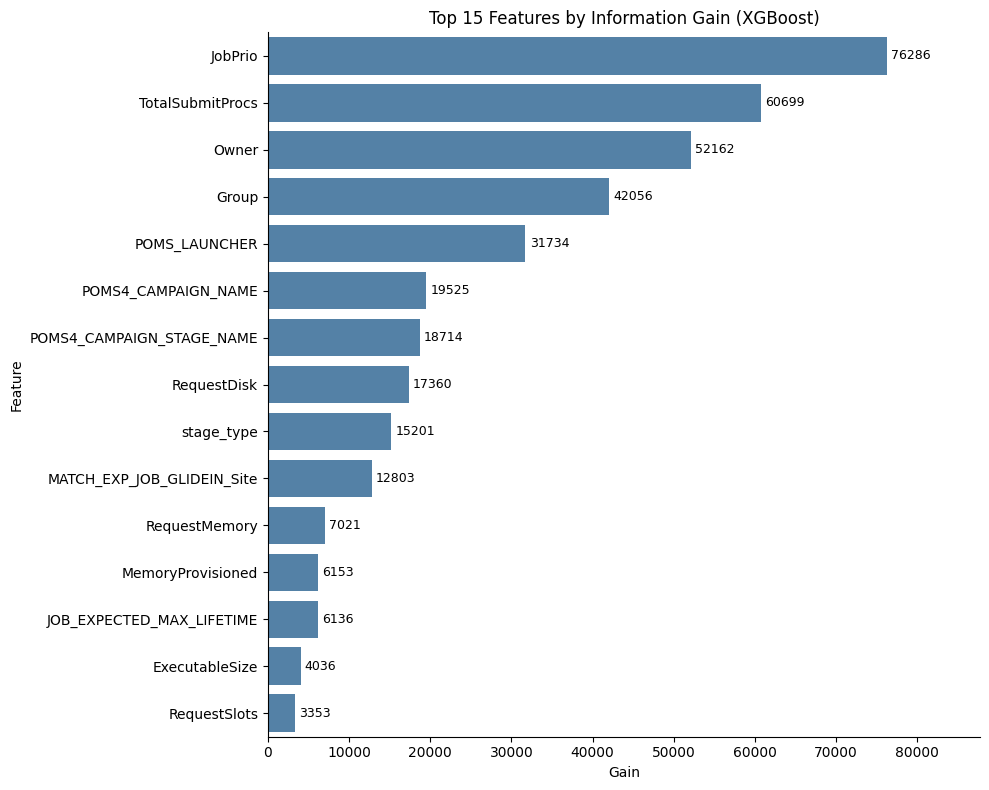

In [18]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=xgb_imp.head(15), x='Gain', y='Feature', color='steelblue')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)
ax.set_xlim(0, xgb_imp['Gain'].max() * 1.15)
plt.title('Top 15 Features by Information Gain (XGBoost)')
sns.despine()
plt.tight_layout()
plt.show()

                     precision    recall  f1-score   support

            Success     0.9011    0.6136    0.7301   4789811
Failure_Application     0.3138    0.6777    0.4289    338243
     Failure_System     0.1434    0.1851    0.1616    645561
Failure_User_Policy     0.0829    0.2854    0.1285    388372

           accuracy                         0.5515   6161987
          macro avg     0.3603    0.4404    0.3623   6161987
       weighted avg     0.7379    0.5515    0.6161   6161987



ROC-AUC (one-vs-rest, macro): 0.6819


              class  precision   recall       f1  support
            Success   0.901094 0.613614 0.730074  4789811
Failure_Application   0.313772 0.677726 0.428950   338243
     Failure_System   0.143362 0.185051 0.161560   645561
Failure_User_Policy   0.082925 0.285350 0.128505   388372


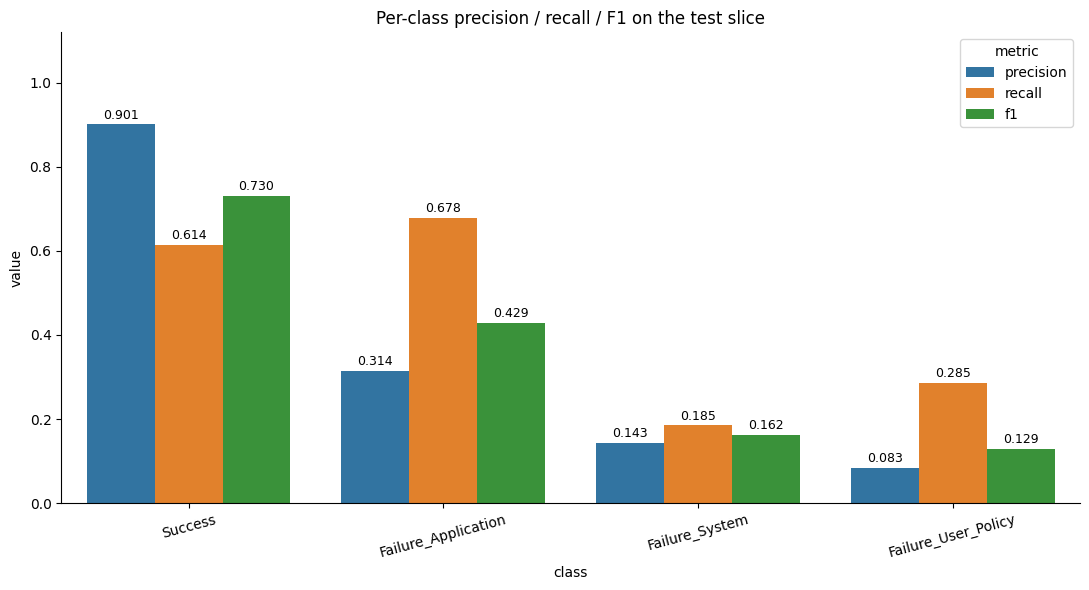

In [19]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, roc_auc_score

CLASS_NAMES = ["Success", "Failure_Application", "Failure_System", "Failure_User"]

y_prob_xgb = model.predict(dtest)      # (n, 4) softprob matrix; uses best_iteration
y_pred_xgb = y_prob_xgb.argmax(axis=1)

print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES, digits=4))
print(f"ROC-AUC (one-vs-rest, macro): "
      f"{roc_auc_score(y_test, y_prob_xgb, multi_class='ovr', average='macro'):.4f}")

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_xgb, labels=[0, 1, 2, 3], zero_division=0)
metrics_df = pd.DataFrame({"class": CLASS_NAMES, "precision": precision,
                           "recall": recall, "f1": f1, "support": support})
print(metrics_df.to_string(index=False))

plot_df = metrics_df.melt(id_vars=["class", "support"], var_name="metric", value_name="value")
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x="class", y="value", hue="metric")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title("Per-class precision / recall / F1 on the test slice")
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

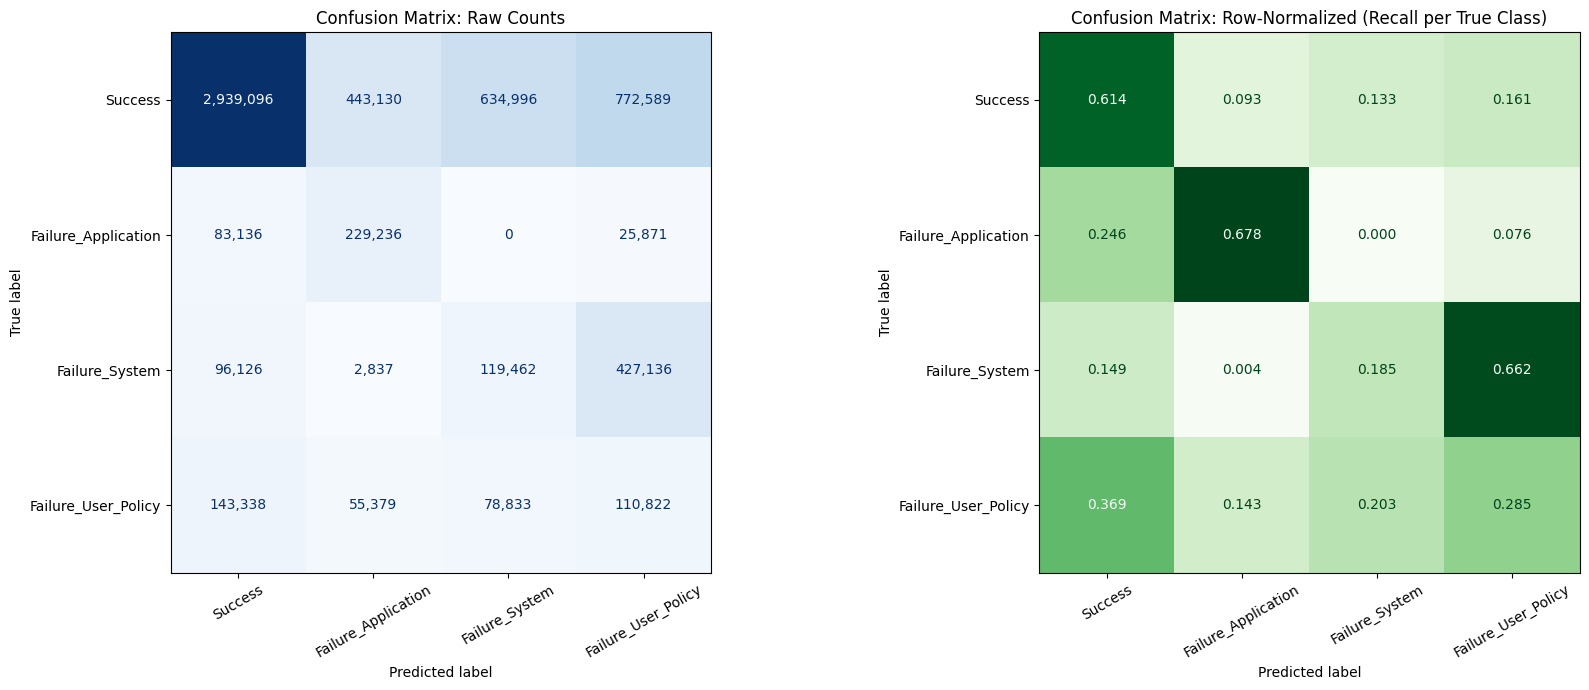

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)
cm_norm = confusion_matrix(y_test, y_pred_xgb, normalize="true")

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax[0], cmap="Blues", values_format=",d", xticks_rotation=30, colorbar=False)
ax[0].set_title("Confusion Matrix: Raw Counts")
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES).plot(
    ax=ax[1], cmap="Greens", values_format=".3f", xticks_rotation=30, colorbar=False)
ax[1].set_title("Confusion Matrix: Row-Normalized (Recall per True Class)")
plt.tight_layout()
plt.show()

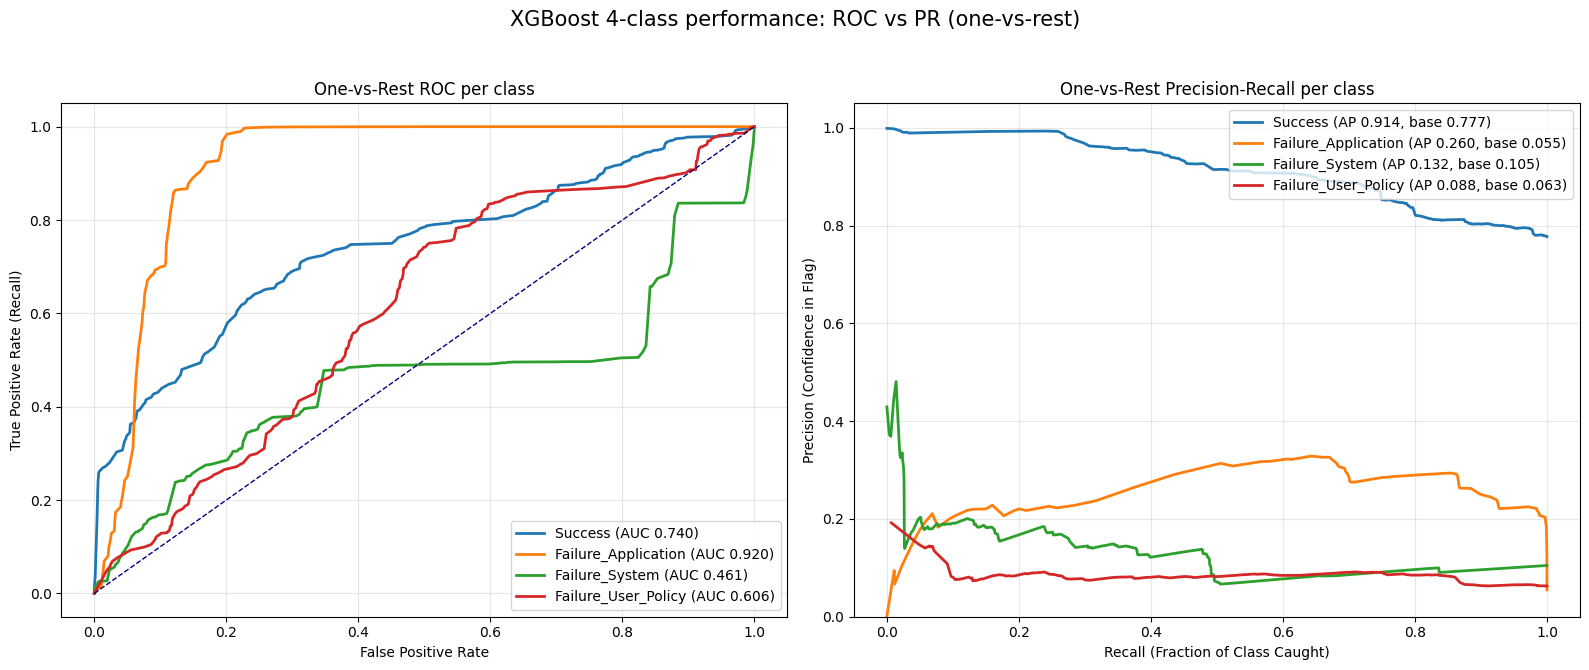

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for k, name in enumerate(CLASS_NAMES):
    y_k = (y_test == k).astype(int)
    p_k = y_prob_xgb[:, k]
    fpr, tpr, _ = roc_curve(y_k, p_k)
    ax1.plot(fpr[::100], tpr[::100], lw=2, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
    prec, rec, _ = precision_recall_curve(y_k, p_k)
    ax2.plot(rec[::100], prec[::100], lw=2,
             label=f"{name} (AP {average_precision_score(y_k, p_k):.3f}, base {y_k.mean():.3f})")

ax1.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("One-vs-Rest ROC per class")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

ax2.set_xlabel("Recall (Fraction of Class Caught)")
ax2.set_ylabel("Precision (Confidence in Flag)")
ax2.set_ylim(0, 1.05)
ax2.set_title("One-vs-Rest Precision-Recall per class")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.suptitle("XGBoost 4-class performance: ROC vs PR (one-vs-rest)", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [22]:
import gc
gc.collect()

5785

## CatBoost

In [163]:
from catboost import CatBoostClassifier, Pool

# train_pool = Pool(data=X_train, label=y_train, cat_features=cat_cols)
train_pool = Pool(data=X_train, label=y_train)

In [164]:
# val_pool = Pool(data=X_test, label=y_test, cat_features=cat_cols)
val_pool = Pool(data=X_test, label=y_test)

In [186]:
%%time
from catboost import CatBoostClassifier, Pool
import gc

model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=10,
    loss_function='Logloss',
    task_type='GPU', 
    devices='0',     
    verbose=100     
)

model_cat.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
    use_best_model=True
)

model_cat.save_model("../models/catboost_v2.cbm")

0:	learn: 0.5472605	test: 0.5473122	best: 0.5473122 (0)	total: 99.7ms	remaining: 1m 39s
100:	learn: 0.0849090	test: 0.0854192	best: 0.0854192 (100)	total: 8.23s	remaining: 1m 13s
200:	learn: 0.0731576	test: 0.0736172	best: 0.0736172 (200)	total: 16.3s	remaining: 1m 4s
300:	learn: 0.0678001	test: 0.0683709	best: 0.0683709 (300)	total: 24.4s	remaining: 56.6s
400:	learn: 0.0652536	test: 0.0659083	best: 0.0659083 (400)	total: 32.4s	remaining: 48.4s
500:	learn: 0.0634240	test: 0.0642128	best: 0.0642128 (500)	total: 40.4s	remaining: 40.2s
600:	learn: 0.0621883	test: 0.0630674	best: 0.0630674 (600)	total: 48.3s	remaining: 32.1s
700:	learn: 0.0612125	test: 0.0622060	best: 0.0622060 (700)	total: 56.3s	remaining: 24s
800:	learn: 0.0604092	test: 0.0615103	best: 0.0615103 (800)	total: 1m 4s	remaining: 16s
900:	learn: 0.0597519	test: 0.0609688	best: 0.0609688 (900)	total: 1m 12s	remaining: 7.96s
999:	learn: 0.0592002	test: 0.0605205	best: 0.0605205 (999)	total: 1m 20s	remaining: 0us
bestTest = 0.06

In [187]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, roc_auc_score, average_precision_score, confusion_matrix

y_pred_cat = model_cat.predict(X_test)
y_prob_cat = model_cat.predict_proba(X_test)[:, 1]

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_cat)

print("--- Metrics for Failure (Class 1) ---")
print(f"Precision: {precision[1]:.6f}")
print(f"Recall:    {recall[1]:.6f}")
print(f"F1-Score:  {f1[1]:.6f}")

print("\n--- Metrics for Success (Class 0) ---")
print(f"Precision: {precision[0]:.6f}")
print(f"Recall:    {recall[0]:.6f}")
print(f"F1-Score:  {f1[0]:.6f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_cat, target_names=['Success', 'Failure']))

print(f"ROC-AUC (TPvFP): {roc_auc_score(y_test, y_prob_cat):.4f}")
print(f"PR-AUC (TNvFN): {average_precision_score(y_test, y_prob_cat):.4f}")

--- Metrics for Failure (Class 1) ---
Precision: 0.907659
Recall:    0.924622
F1-Score:  0.916062

--- Metrics for Success (Class 0) ---
Precision: 0.987296
Recall:    0.984196
F1-Score:  0.985743

--- Classification Report ---
              precision    recall  f1-score   support

     Success       0.99      0.98      0.99   1276160
     Failure       0.91      0.92      0.92    214412

    accuracy                           0.98   1490572
   macro avg       0.95      0.95      0.95   1490572
weighted avg       0.98      0.98      0.98   1490572

ROC-AUC (TPvFP): 0.9950
PR-AUC (TNvFN): 0.9751


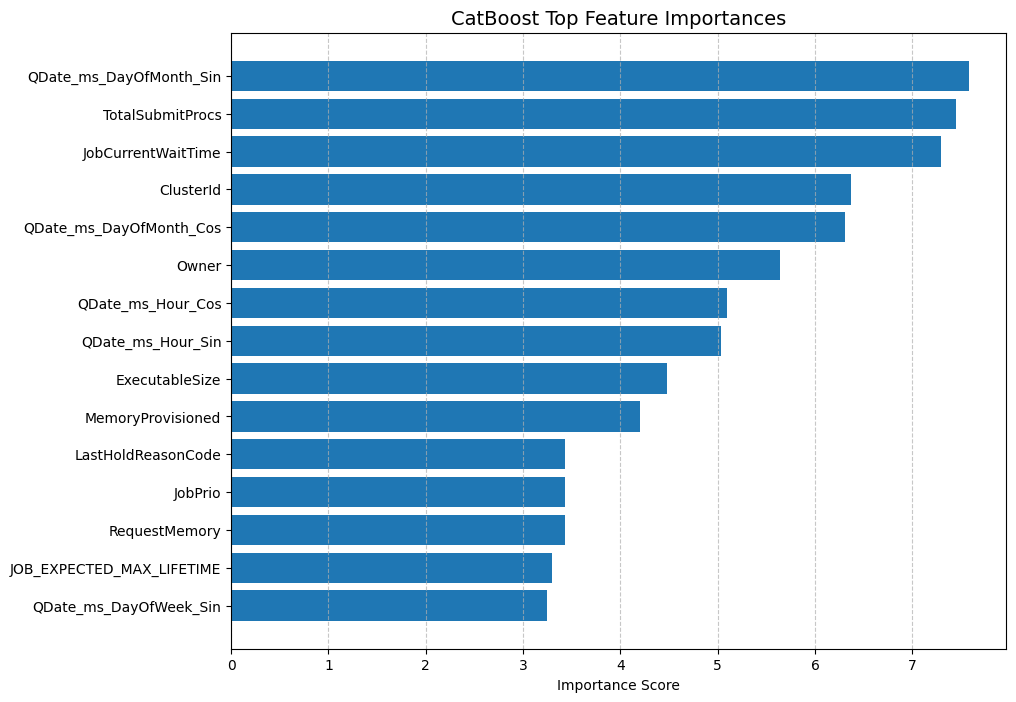

                      Feature  Importance
19    QDate_ms_DayOfMonth_Sin    7.584332
14           TotalSubmitProcs    7.448087
3          JobCurrentWaitTime    7.291360
25                  ClusterId    6.369864
20    QDate_ms_DayOfMonth_Cos    6.309633
24                      Owner    5.643058
16          QDate_ms_Hour_Cos    5.095180
15          QDate_ms_Hour_Sin    5.035096
1              ExecutableSize    4.475515
13          MemoryProvisioned    4.203893
34         LastHoldReasonCode    3.428924
32                    JobPrio    3.428456
7               RequestMemory    3.426416
2   JOB_EXPECTED_MAX_LIFETIME    3.296815
17     QDate_ms_DayOfWeek_Sin    3.247668


In [188]:
importances = model_cat.get_feature_importance(type='FeatureImportance')
feature_names = X_df.columns
cb_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
cb_imp = cb_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(cb_imp['Feature'].head(15)[::-1], cb_imp['Importance'].head(15)[::-1])
plt.title('CatBoost Top Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(cb_imp.head(15))

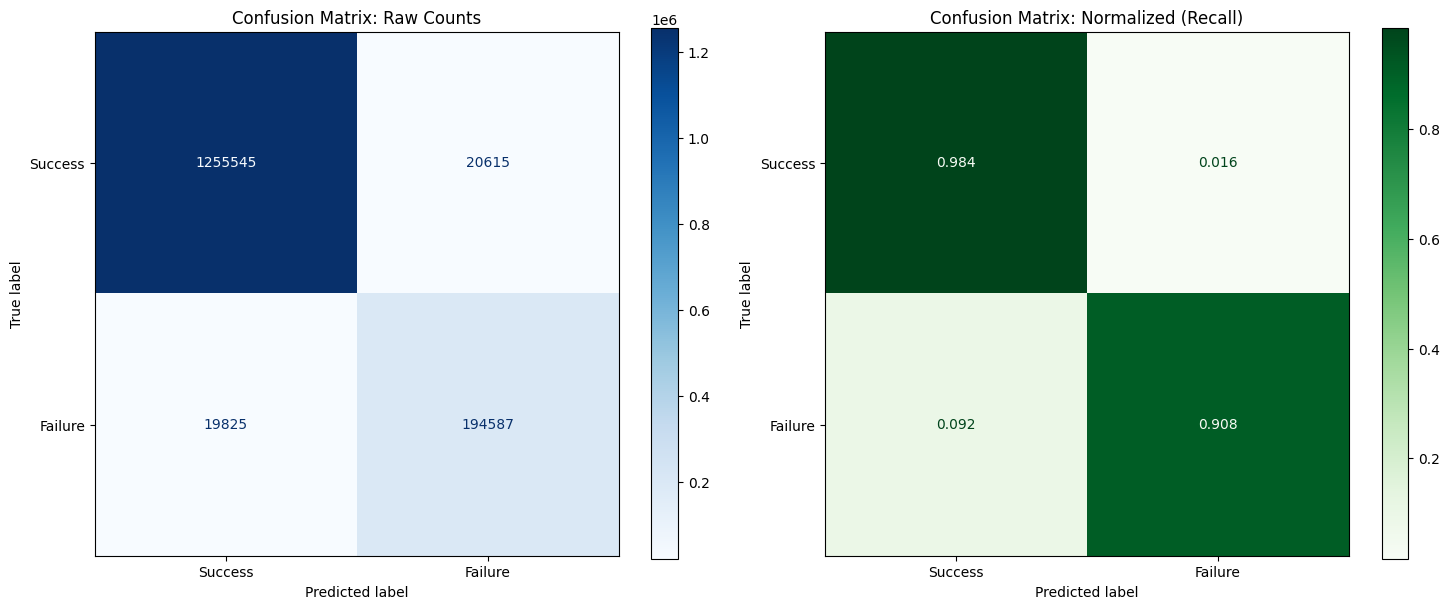

Raw Confusion Matrix:
[[1255545   20615]
 [  19825  194587]]
Normalized Confusion Matrix:
[[0.98384607 0.01615393]
 [0.09246218 0.90753782]]


In [180]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

cm_cat = confusion_matrix(y_test, y_pred_cat)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=['Success', 'Failure'])
disp_raw.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Confusion Matrix: Raw Counts')

cm_norm_cat = confusion_matrix(y_test, y_pred_cat, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Success', 'Failure'])
disp_norm.plot(ax=ax[1], cmap='Greens', values_format='.3f')
ax[1].set_title('Confusion Matrix: Normalized (Recall)')

plt.tight_layout()
plt.show()

print("Raw Confusion Matrix:")
print(cm_cat)
print("Normalized Confusion Matrix:")
print(cm_norm_cat)

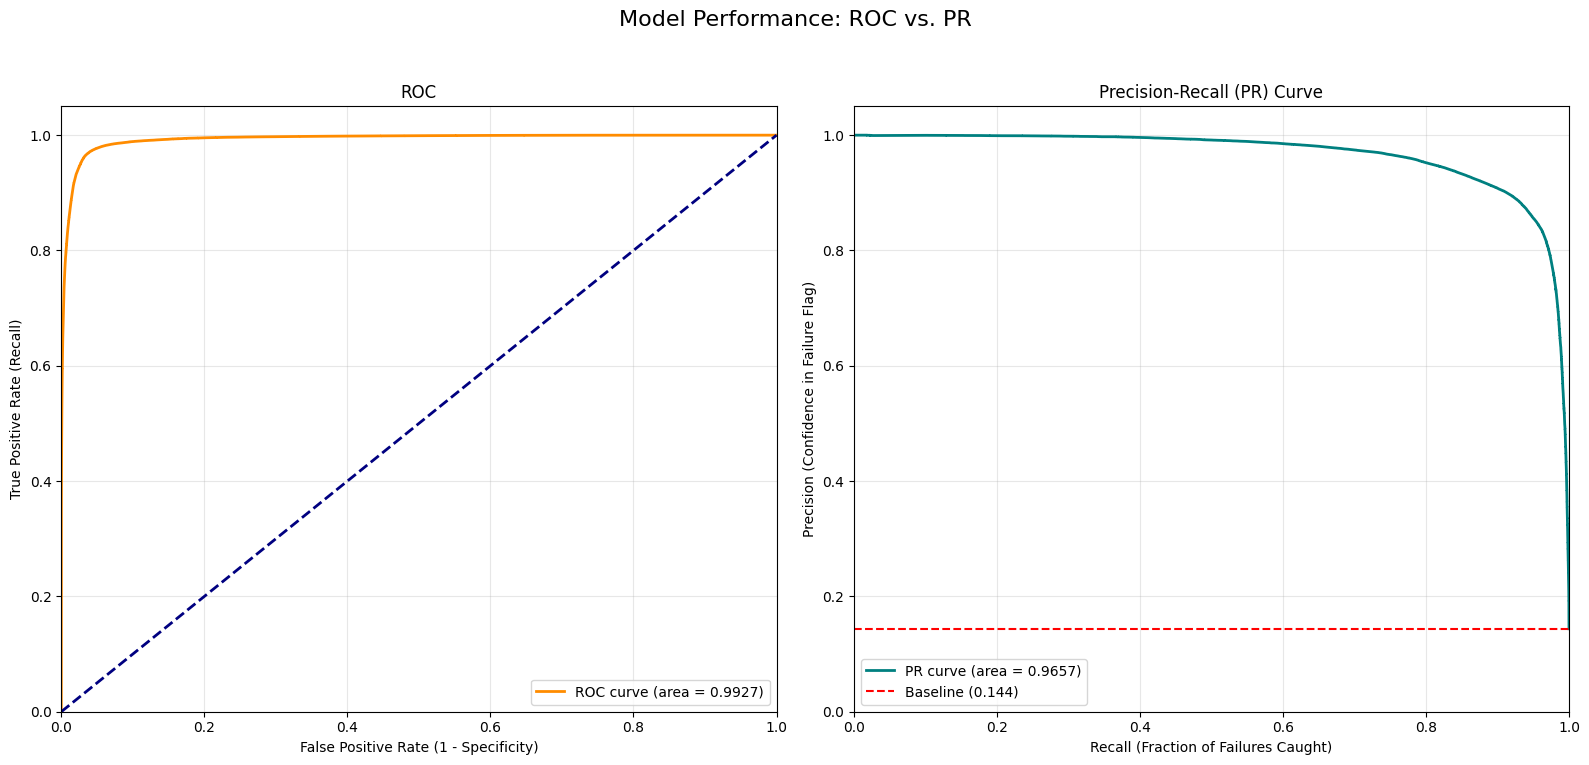

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_test, y_prob_cat)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob_cat)
pr_auc = average_precision_score(y_test, y_prob_cat)
baseline = y_test.sum() / len(y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal baseline
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

ax2.plot(recall, precision, color='teal', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Fraction of Failures Caught)')
ax2.set_ylabel('Precision (Confidence in Failure Flag)')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.suptitle('Model Performance: ROC vs. PR', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [189]:
del model_cat
gc.collect()

4713

## LightGBM

In [40]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [44]:
cat_indices = [X_df.columns.index(col) for col in cat_cols]

In [182]:
import numpy as np 

X_train_np = np.array(X_train)
y_train_np = np.array(y_train).ravel()
X_test_np = np.array(X_test)
y_test_np = np.array(y_test).ravel()

In [183]:
%%time
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    num_leaves=31,         
    device='cpu',          
    importance_type='gain', 
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
   #  categorical_feature=cat_indices,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), 
        lgb.log_evaluation(100)
    ]
)

y_pred_lgb = model_lgb.predict(X_test)
y_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]

print("\n--- LightGBM Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_lgb))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 1215002, number of negative: 7231570
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.326618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2301
[LightGBM] [Info] Number of data points in the train set: 8446572, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143846 -> initscore=-1.783710
[LightGBM] [Info] Start training from score -1.783710
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0912239
[200]	valid_0's binary_logloss: 0.0789365
[300]	valid_0's binary_logloss: 0.073284
[400]	valid_0's binary_logloss: 0.06971
[500]	valid_0's binary_logloss: 0.0674978
[600]	valid_0's binary_logloss: 0.0667721
Early stopping, best iteration is:
[563]	valid_0's binary_logloss: 0.0663621


/home/amaustin/miniconda3/envs/p311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/amaustin/miniconda3/envs/p311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- LightGBM Confusion Matrix ---
[[1255963   20197]
 [  17822  196590]]

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99   1276160
         1.0       0.91      0.92      0.91    214412

    accuracy                           0.97   1490572
   macro avg       0.95      0.95      0.95   1490572
weighted avg       0.97      0.97      0.97   1490572

CPU times: user 9h 20min 52s, sys: 1min 13s, total: 9h 22min 5s
Wall time: 7min 3s


In [184]:
import joblib 

joblib.dump(model_lgb, '../models/lgbm_model_v2.pkl')

['../models/lgbm_model_v2.pkl']

In [185]:
print(f"ROC-AUC (TPvFP): {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(f"PR-AUC (TNvFN): {average_precision_score(y_test, y_prob_lgb):.4f}")

ROC-AUC (TPvFP): 0.9940
PR-AUC (TNvFN): 0.9709


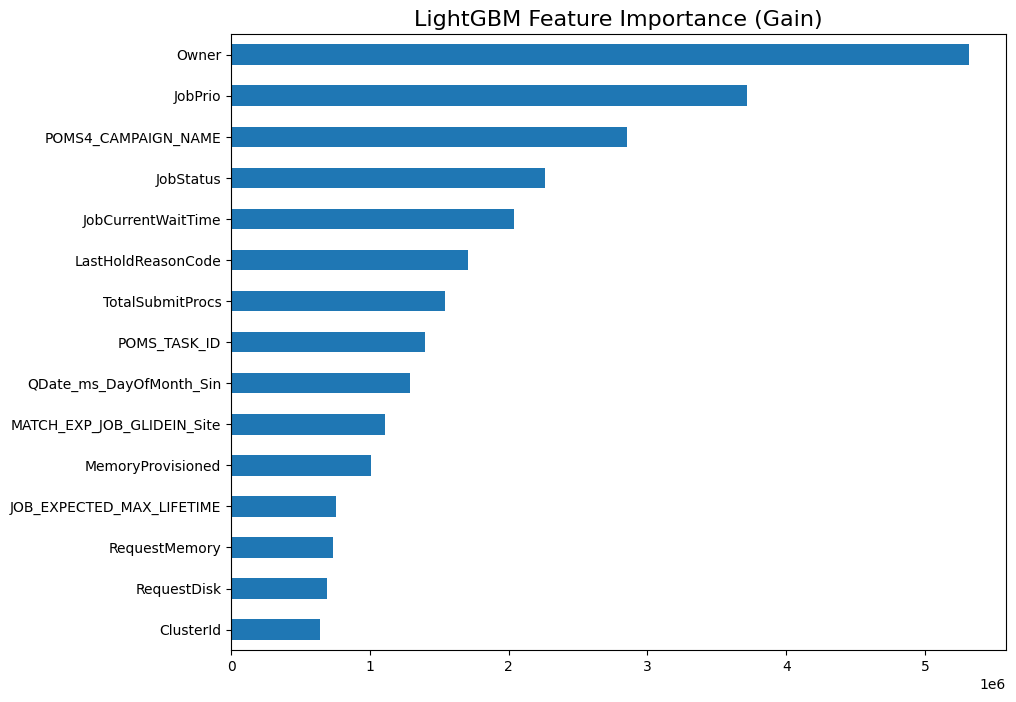

In [190]:
import matplotlib.pyplot as plt
import pandas as pd

lgb_imp = pd.Series(model_lgb.feature_importances_, index=X_df.columns)
lgb_imp = lgb_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
lgb_imp.head(15)[::-1].plot(kind='barh')
plt.title("LightGBM Feature Importance (Gain)", fontsize=16)
plt.show()

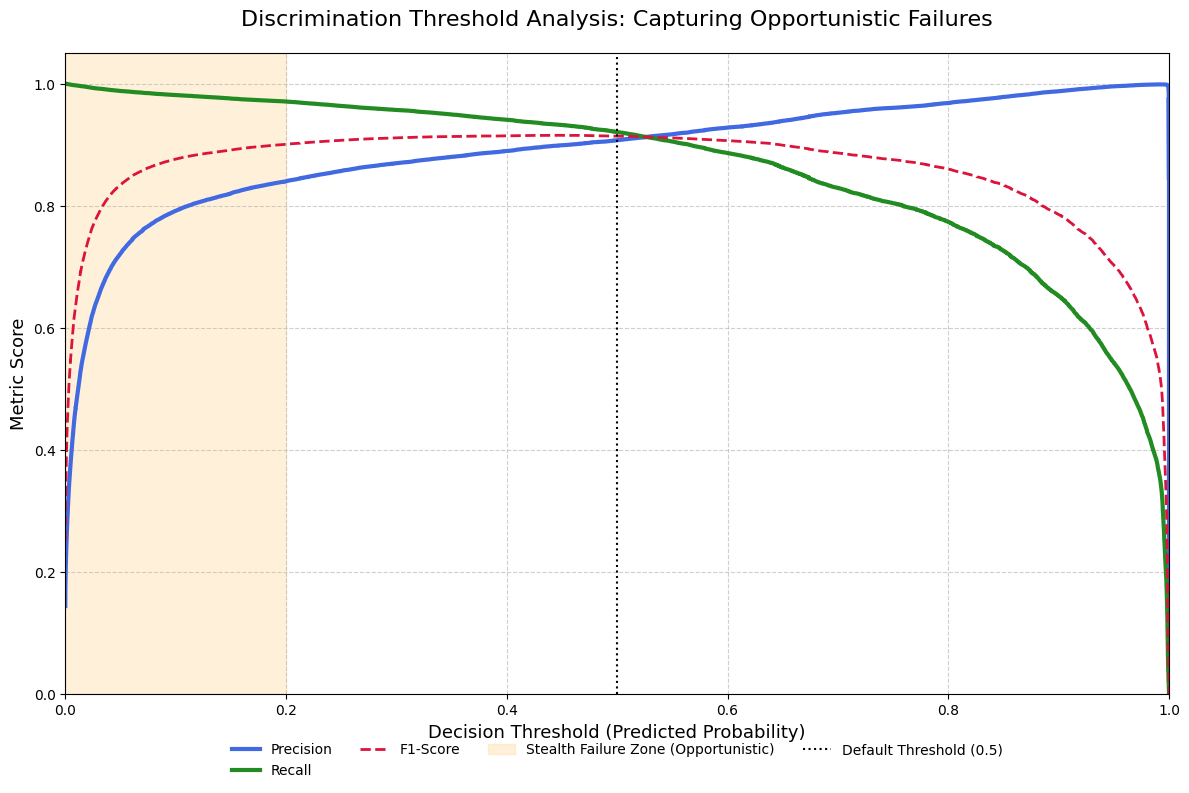

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgb)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10) 

plt.figure(figsize=(12, 8), facecolor='white')
plt.plot(thresholds, precision[:-1], label='Precision', color='royalblue', lw=3)
plt.plot(thresholds, recall[:-1], label='Recall', color='forestgreen', lw=3)
plt.plot(thresholds, f1[:-1], label='F1-Score', color='crimson', lw=2, linestyle='--')

plt.axvspan(0, 0.2, color='orange', alpha=0.15, label='Stealth Failure Zone (Opportunistic)')
plt.axvline(x=0.5, color='black', linestyle=':', label='Default Threshold (0.5)')

plt.title('Discrimination Threshold Analysis: Capturing Opportunistic Failures', fontsize=16, pad=20)
plt.xlabel('Decision Threshold (Predicted Probability)', fontsize=13)
plt.ylabel('Metric Score', fontsize=13)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [196]:
def normalize_dict(d):
    if isinstance(d, pd.Series):
        d = d.to_dict()
    max_val = max(d.values()) if d.values() else 1
    return {k: v / max_val for k, v in d.items()}

importances = {
    'xgb': normalize_dict(xgb_imp.set_index('Feature')['Gain'].to_dict()),
    'catboost': normalize_dict(cb_imp.set_index('Feature')['Importance'].to_dict()),
    'lgb': normalize_dict(lgb_imp),
}
importances

{'xgb': {'JobPrio': 1.0,
  'QDate_ms_Month_Sin': 0.6222151923053248,
  'POMS4_CAMPAIGN_NAME': 0.30065362061652456,
  'Owner': 0.23149376242022796,
  'JobUniverse': 0.22845445080162813,
  'JobStatus': 0.1316920663864565,
  'LastHoldReasonCode': 0.07459004154656017,
  'POMS_TASK_ID': 0.05931853307851542,
  'QDate_ms_Month_Cos': 0.05262067975648799,
  'RequestDisk': 0.05143715583821127,
  'TotalSubmitProcs': 0.04810983109422605,
  'RequestSlots': 0.04541444810820833,
  'MemoryProvisioned': 0.04157031411169187,
  'POMS4_CAMPAIGN_STAGE_ID': 0.039091225420212664,
  'RequestMemory': 0.03455462699306538,
  'JOB_EXPECTED_MAX_LIFETIME': 0.031504946920604175,
  'MATCH_EXP_JOB_GLIDEIN_Site': 0.0314860822567426,
  'ExecutableSize': 0.03122845870356975,
  'QDate_ms_DayOfMonth_Sin': 0.031162109458790492,
  'QDate_ms_DayOfMonth_Cos': 0.01652640264872844,
  'Group': 0.01539363915523611,
  'QDate_ms_DayOfWeek_Cos': 0.014984440790835806,
  'POMS_LAUNCHER': 0.010985084255170564,
  'QDate_ms_DayOfWeek_Sin'

In [207]:
import polars as pl

dfs = []
for model_name, scores in importances.items():
    df = pl.DataFrame({
        "feature": list(scores.keys()),
        model_name: list(scores.values())
    })
    dfs.append(df)

importances_final = dfs[0]
for next_df in dfs[1:]:
    importances_final = importances_final.join(next_df, on="feature", how="full")

importances_final = importances_final.drop("feature_right").fill_null(0)
importances_final

feature,xgb,catboost,lgb
str,f64,f64,f64
"""Owner""",0.231494,0.744041,1.0
"""JobPrio""",1.0,0.452044,0.699438
"""POMS4_CAMPAIGN_NAME""",0.300654,0.253617,0.536967
"""JobStatus""",0.131692,0.340481,0.425549
"""JobCurrentWaitTime""",0.006897,0.961371,0.383203
…,…,…,…
"""CpusProvisioned""",0.00838,0.032439,0.001952
"""CoreSize""",0.00588,0.016987,0.001539
"""TransferInputSizeMB""",0.002868,0.000639,0.001393


In [209]:
importances_final.write_parquet("../data/dash/importances.parquet")